# 01 — Data Acquisition, Quality Control and Exploratory Analysis

**PortfolioRL** · Deep Q-Network agent for dynamic multi-asset portfolio rebalancing

---

| | |
|---|---|
| **Purpose** | Acquire and freeze the market dataset, prove it is clean, engineer the agent's observation vector, and establish that the state features carry economically meaningful signal. |
| **Inputs** | Yahoo! Finance (network, first run only), then `data/raw/` cache |
| **Outputs** | `data/raw/*.csv`, `data/processed/*.csv`, `data/processed/scaler.json`, 14 figures in `artifacts/figures/` |
| **Runtime** | ~30 s from cache, ~60 s on first download |
| **Serves** | Assignment criteria *Data Preparation* and *Documentation* |

---

## What this notebook has to establish

A reinforcement learning agent can only be as good as the state it observes. Three
things must be true before any training happens, and each one is *demonstrated*
here rather than asserted:

1. **The data is real and frozen.** Free market data is silently revised. Every
   result in this project must be reproducible from an on-disk snapshot, not
   from a live endpoint.
2. **The features are causal.** A feature stamped at date $t$ must be computable
   strictly before $t$. The single most common way a backtest produces a
   fictitious Sharpe ratio is by leaking one day of future information. Section 6
   shows exactly what that leak looks like.
3. **The regimes differ.** If the training, validation and test periods were
   statistically identical, a policy that simply memorised the training path
   would appear to generalise. Sections 4 and 5 show they are not identical —
   which makes the test result meaningful *and* makes the problem hard.

## 1. Setup

All configuration lives in `portfoliorl.config`; nothing is hard-coded in a cell.
A run is therefore fully described by a small set of frozen dataclasses, which is
what makes the experiments reproducible.

All plotting goes through `portfoliorl.plots`, so every figure in the project
shares one palette (SPY = blue, TLT = red, GLD = gold, SHY = grey) and is exported
to disk at report resolution as a side effect of being displayed.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter, ScalarFormatter
from scipy import stats

from portfoliorl import config, data, features, plots, utils

warnings.filterwarnings("ignore", category=FutureWarning)

plots.apply_style()          # project-wide Matplotlib defaults
config.ensure_dirs()         # create data/ and artifacts/ trees
utils.set_global_seed(0)     # this notebook has no stochastic step, but be consistent

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

CFG = config.DEFAULT.data
print(f"Project root : {config.PROJECT_ROOT}")
print(f"Universe     : {', '.join(CFG.tickers)}  (+ risk-free proxy {CFG.risk_free_ticker})")
print(f"Sample       : {CFG.start} .. {CFG.end}")

Project root : C:\Github\PortfolioRL
Universe     : SPY, TLT, GLD, SHY  (+ risk-free proxy ^IRX)
Sample       : 2004-11-01 .. 2025-12-31


### 1.1 The configuration under test

Printing the configuration into the notebook means the committed output is
self-documenting: a reader can see which parameters produced these figures
without opening the source.

In [2]:
split_table = pd.DataFrame(
    [
        {"split": name, "start": start, "end": end}
        for name, (start, end) in data.split_bounds(CFG).items()
    ]
).set_index("split")

lookback_table = pd.DataFrame(
    {
        "trading days": [
            CFG.vol_window,
            CFG.vol_window_long,
            CFG.momentum_window,
            CFG.ma_fast,
            CFG.ma_slow,
        ]
    },
    index=["vol (short)", "vol (long)", "momentum", "MA fast", "MA slow"],
)

display(split_table)
display(lookback_table.T)
print(f"Feature warm-up required before the sample can start: {CFG.warmup_days} trading days")

,start,end
split,,
train,2004-11-18,2017-12-31
valid,2018-01-01,2020-12-31
test,2021-01-01,2025-12-31


,vol (short),vol (long),momentum,MA fast,MA slow
trading days,20,60,63,50,200


Feature warm-up required before the sample can start: 200 trading days


**Why these dates.** The sample starts at GLD's inception (2004-11-18); SPY, TLT
and SHY all pre-date it, so this is the earliest date on which the full universe
is investable. Starting here places the 2008 global financial crisis *inside the
training window* — a policy that has never seen a bear market cannot reasonably
be expected to behave in one.

The splits are **strictly chronological and non-overlapping**. Random or k-fold
splitting would leak future information through the strong autocorrelation of
volatility, which is precisely the signal the agent trades on.

## 2. Download and freeze the data

Three details of the `yfinance` API are easy to get wrong and each produces a
silently different dataset:

1. **`auto_adjust=True` is the default.** The returned `Close` column is already
   adjusted for splits and dividends, and there is **no `Adj Close` column at
   all**. Code copied from older tutorials raises `KeyError` here — or worse,
   uses raw closes and books a fake −2% return on every ex-dividend date.
2. **Multi-ticker downloads return a two-level column index** `(Price, Ticker)`.
3. **`end` is exclusive.** `portfoliorl.data` adds one day so the configured end
   date is genuinely included.

The first run hits the network and writes CSVs into `data/raw/` along with a
manifest recording when the snapshot was taken. Every subsequent run — and every
later notebook — reads only the cache.

In [3]:
# Cache-first: pass force=True only when you deliberately want a fresh snapshot.
prices_raw, volumes = data.download_market_data(CFG)
rf_raw = data.download_risk_free(CFG)

manifest = data.cache_manifest()
print("Cache manifest")
for key, value in manifest.items():
    print(f"  {key:<22} {value}")

print(f"\nPrice frame: {prices_raw.shape[0]:,} rows x {prices_raw.shape[1]} tickers")
display(prices_raw.head(3))
display(prices_raw.tail(3))

Cache manifest
  downloaded_utc         2026-07-25T16:34:20+00:00
  tickers                ['SPY', 'TLT', 'GLD', 'SHY']
  requested_start        2004-11-01
  requested_end          2025-12-31
  actual_first_date      2004-11-01
  actual_last_date       2025-12-31
  n_rows                 5326
  yfinance_auto_adjust   True

Price frame: 5,326 rows x 4 tickers


,SPY,TLT,GLD,SHY
date,,,,
2004-11-01,76.007561,43.605106,NaN,54.083775
2004-11-02,76.034378,43.669147,NaN,54.110168
2004-11-03,76.991913,43.688854,NaN,54.103546


,SPY,TLT,GLD,SHY
date,,,,
2025-12-29,684.213867,86.117188,398.600006,81.392456
2025-12-30,683.378357,85.911835,398.890015,81.412109
2025-12-31,678.315247,85.227364,396.309998,81.382629


## 3. Data quality control

The checks below are chosen for the specific ways free market data fails, not as
a generic "describe the dataframe" ritual:

| Check | Failure it catches |
|---|---|
| `first_date` / `n_missing` | A symbol that did not exist yet, silently forward-filled into a fake price history |
| `n_zero_returns` | A stale feed — a run of identical closes looks to the agent like a risk-free asset |
| `n_extreme_moves` (>20% in a day) | An unadjusted split or a bad print, which would hand the agent an impossible reward |
| `ann_vol` | A sanity check against known asset behaviour (SPY ≈ 19%, SHY ≈ 1.5%) |

In [4]:
report = data.quality_report(prices_raw, volumes)
display(
    report.style.format(
        {
            "pct_missing": "{:.2%}",
            "max_abs_move": "{:.2%}",
            "ann_vol": "{:.2%}",
            "median_volume": "{:,.0f}",
        }
    ).set_caption("Table 1 — Data quality report, full sample")
)

,first_date,last_date,n_obs,n_missing,pct_missing,n_zero_returns,n_extreme_moves,max_abs_move,ann_vol,median_volume
ticker,,,,,,,,,,
SPY,2004-11-01,2025-12-31,5326,0,0.00%,16,0,14.52%,18.99%,"91,742,100"
TLT,2004-11-01,2025-12-31,5326,0,0.00%,25,0,7.52%,14.64%,"7,846,500"
GLD,2004-11-18,2025-12-31,5313,13,0.24%,20,0,11.29%,17.65%,"7,908,800"
SHY,2004-11-01,2025-12-31,5326,0,0.00%,469,0,1.00%,1.49%,"1,275,900"


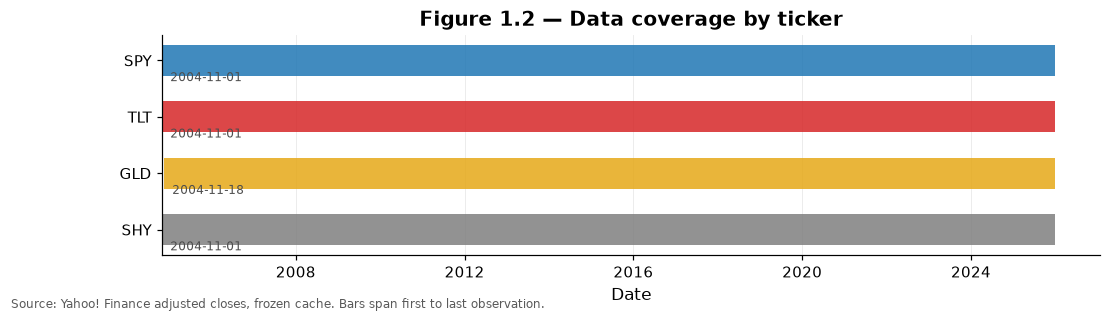

In [5]:
# Figure 1.2 — coverage timeline.
# Plotted on the UNTRIMMED frame so that the inception constraint driving the
# sample start date is visible rather than assumed.
fig, ax = plt.subplots(figsize=(11, 2.6))

for i, ticker in enumerate(prices_raw.columns):
    series = prices_raw[ticker].dropna()
    ax.barh(
        i,
        width=series.index.max() - series.index.min(),
        left=series.index.min(),
        height=0.55,
        color=plots.ASSET_COLORS[ticker],
        alpha=0.85,
    )
    ax.text(
        series.index.min(),
        i + 0.42,
        f"  {series.index.min().date()}",
        va="bottom",
        fontsize=8,
        color="0.3",
    )

ax.set_yticks(range(len(prices_raw.columns)), prices_raw.columns)
ax.invert_yaxis()
ax.set_title("Figure 1.2 — Data coverage by ticker")
ax.set_xlabel("Date")
ax.grid(axis="y", visible=False)
plots.caption(fig, "Source: Yahoo! Finance adjusted closes, frozen cache. Bars span first to last observation.")

plots.save_fig(fig, "01_02_data_coverage")
plt.show()

**What this shows.** All four series are complete over the requested window with
zero missing observations and zero suspect ticks. `SHY`'s several hundred
zero-return days are genuine, not a stale feed: a 1–3 year Treasury ETF trading
around \$80 frequently closes unchanged to the cent.

The realised annualised volatilities (SPY ≈ 19%, GLD ≈ 18%, TLT ≈ 15%, SHY ≈ 1.5%)
match the published characteristics of these funds, which is a meaningful
end-to-end check that the adjustment logic is correct — an unadjusted price series
would show materially higher volatility because of dividend drops.

In [6]:
# Restrict to dates where the ENTIRE universe is tradable. An episode in which
# one asset has no price is not a portfolio problem, so those rows are dropped
# outright rather than imputed.
prices, rf = data.align_and_trim(prices_raw, rf_raw, CFG)

returns = prices.pct_change().dropna()
print(f"Aligned sample : {len(prices):,} trading days")
print(f"               : {prices.index.min().date()} .. {prices.index.max().date()}")
print(f"Risk-free (daily decimal) mean {rf.mean():.6f}  ->  {rf.mean() * 252:.2%} annualised")

Aligned sample : 5,313 trading days
               : 2004-11-18 .. 2025-12-31
Risk-free (daily decimal) mean 0.000067  ->  1.70% annualised


## 4. What the agent is trading

The four ETFs are not an arbitrary basket. They span the risk dimensions that a
tactical allocator is supposed to rotate between:

| Ticker | Exposure | Role in the policy |
|---|---|---|
| **SPY** | US large-cap equity | Growth engine; the thing to own in expansions |
| **TLT** | 20+ year Treasuries | Duration; the classic equity hedge — until it isn't |
| **GLD** | Gold bullion | Inflation and tail hedge, uncorrelated with both |
| **SHY** | 1–3 year Treasuries | Cash-like refuge; near-zero volatility |

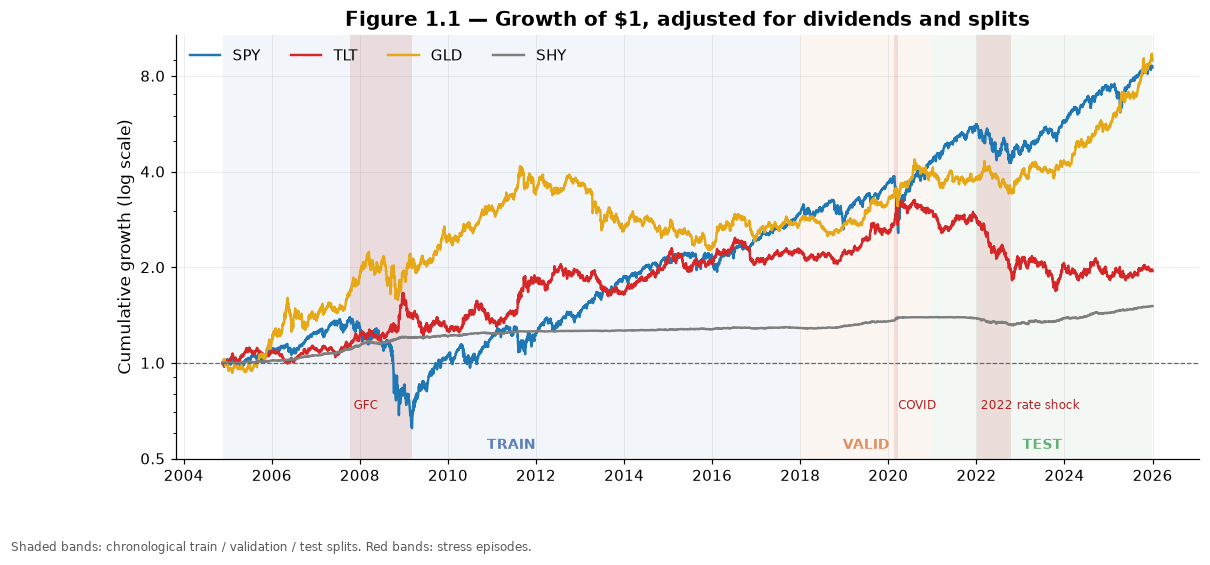

In [7]:
# Figure 1.1 — the whole dataset in one chart.
# Log y-axis: on a linear axis a 20-year equity chart makes the 2008 crash look
# smaller than a routine 2023 wobble, because equal vertical distances would
# represent very unequal percentage moves.
fig, ax = plt.subplots(figsize=(12, 5))

growth = prices / prices.iloc[0]
for ticker in prices.columns:
    ax.plot(growth.index, growth[ticker], color=plots.ASSET_COLORS[ticker], label=ticker)

ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 4, 8])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.axhline(1.0, color="0.4", lw=0.8, ls="--")

plots.shade_splits(ax, CFG)
plots.annotate_crises(ax, label=True)

ax.set_title("Figure 1.1 — Growth of $1, adjusted for dividends and splits")
ax.set_ylabel("Cumulative growth (log scale)")
ax.legend(ncol=4, loc="upper left")
plots.tidy_dates(ax, interval=2)
plots.caption(fig, "Shaded bands: chronological train / validation / test splits. Red bands: stress episodes.")

plots.save_fig(fig, "01_01_asset_growth")
plt.show()

**What this shows.** Three observations that shape the entire problem:

1. **No asset dominates throughout.** GLD leads from 2005 to 2012, SPY leads from
   2013 onward, TLT leads through 2008 and again in 2020, then gives back a decade
   of gains in 2022. A static allocation is a bet that one ordering persists; the
   chart says it does not. This is the economic case for a *dynamic* policy.
2. **The test window is not a gentle one.** It opens with the 2021 melt-up,
   contains the worst bond drawdown in modern history, and ends in a
   concentrated equity bull market. That is a genuine out-of-sample challenge,
   not a victory lap.
3. **The training window contains the GFC.** The agent will have seen a −50%
   equity drawdown and a flight-to-quality bond rally before it is ever evaluated.

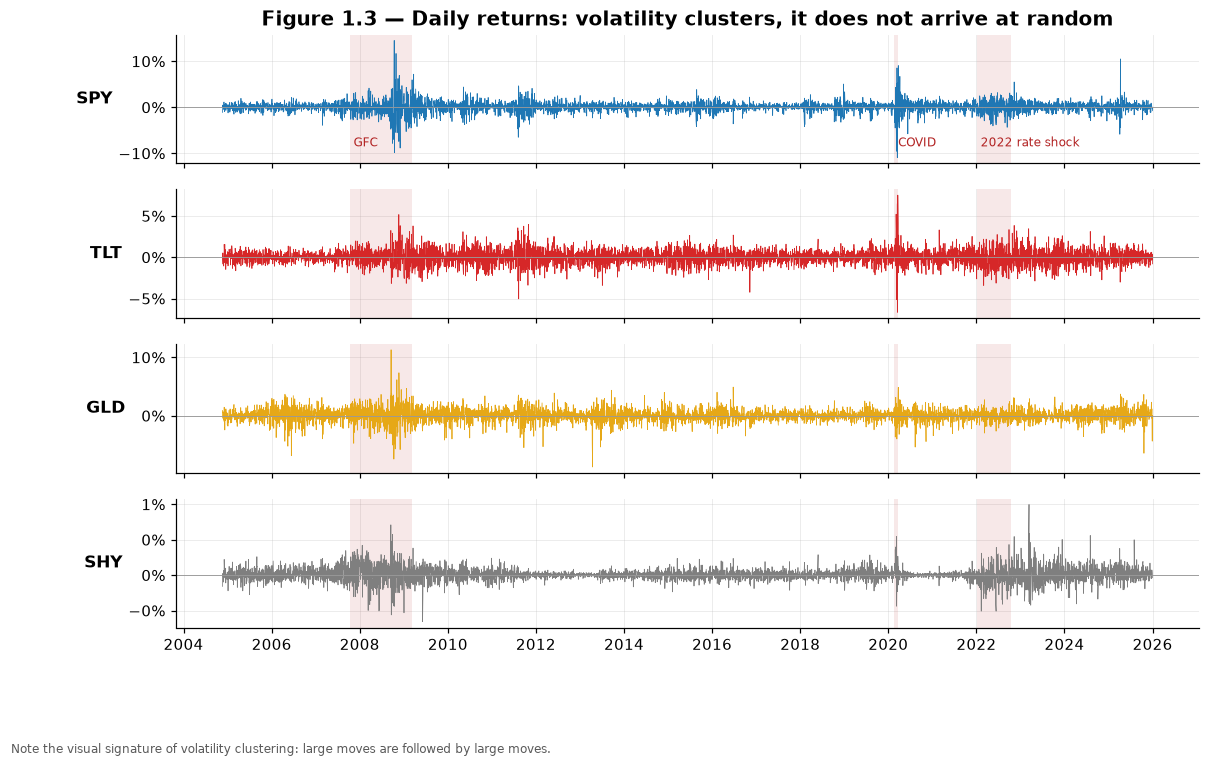

In [8]:
# Figure 1.3 — daily return series, one panel per asset, shared x-axis.
# Separate panels rather than one overlay: the volatility scales differ by more
# than 10x, so SHY would be an invisible flat line next to SPY.
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 7), sharex=True)

for ax, ticker in zip(axes, returns.columns):
    ax.plot(returns.index, returns[ticker], color=plots.ASSET_COLORS[ticker], lw=0.5)
    ax.set_ylabel(ticker, rotation=0, ha="right", va="center", fontweight="bold")
    plots.annotate_crises(ax, alpha=0.10, label=False)
    plots.format_pct_axis(ax, decimals=0)
    ax.axhline(0, color="0.6", lw=0.6)

plots.annotate_crises(axes[0], alpha=0.0, label=True)
axes[0].set_title("Figure 1.3 — Daily returns: volatility clusters, it does not arrive at random")
plots.tidy_dates(axes[-1], interval=2)
plots.caption(fig, "Note the visual signature of volatility clustering: large moves are followed by large moves.")

plots.save_fig(fig, "01_03_daily_returns")
plt.show()

**What this shows — and why it is the justification for the whole approach.**
Volatility *clusters*. Turbulent days arrive in runs, not independently. This is
the property that makes the problem learnable at all: today's realised volatility
predicts tomorrow's, so a rolling volatility feature carries genuine information
about the state of the world.

If returns were i.i.d., no observable state could improve on a fixed allocation
and the optimal policy would be constant — there would be no MDP worth solving.

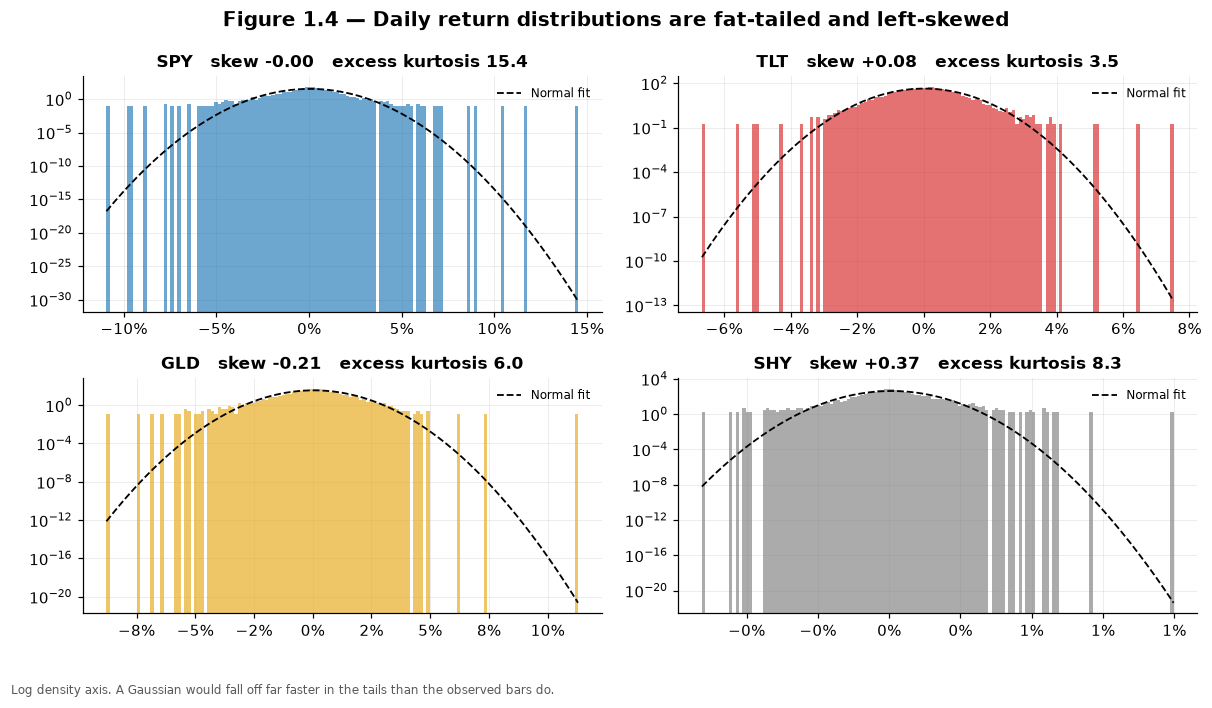

In [9]:
# Figure 1.4 — return distributions against the Gaussian they are usually
# assumed to follow.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

for ax, ticker in zip(axes.ravel(), returns.columns):
    series = returns[ticker]
    ax.hist(series, bins=140, density=True, color=plots.ASSET_COLORS[ticker], alpha=0.65)

    grid = np.linspace(series.min(), series.max(), 400)
    ax.plot(grid, stats.norm.pdf(grid, series.mean(), series.std()), "k--", lw=1.2,
            label="Normal fit")

    ax.set_yscale("log")  # log density makes the tails, not the peak, the visual story
    ax.set_title(
        f"{ticker}   skew {series.skew():+.2f}   excess kurtosis {series.kurtosis():.1f}",
        fontsize=11,
    )
    plots.format_pct_axis(ax, axis="x", decimals=0)
    ax.legend(fontsize=8)

fig.suptitle("Figure 1.4 — Daily return distributions are fat-tailed and left-skewed", fontweight="bold")
fig.tight_layout()
plots.caption(fig, "Log density axis. A Gaussian would fall off far faster in the tails than the observed bars do.")

plots.save_fig(fig, "01_04_return_distributions")
plt.show()

**What this shows, and two decisions it forces.**

Every series has substantial excess kurtosis and negative skew: extreme losses are
far more frequent than a normal distribution predicts, and the left tail is heavier
than the right. Two consequences propagate through the rest of the project:

1. **The Sharpe ratio alone is not sufficient.** It penalises upside and downside
   deviation identically. The results section reports the **Sortino ratio** and
   **maximum drawdown** alongside it, precisely because this distribution is
   asymmetric.
2. **Confidence intervals cannot assume i.i.d. normal returns.** Notebook 05 uses
   a **stationary block bootstrap**, which resamples contiguous blocks and
   therefore preserves both the fat tails and the volatility clustering seen in
   Figure 1.3. A textbook $\sigma/\sqrt{n}$ interval would be far too narrow here.

## 5. Regime structure — why a *dynamic* policy can add value

A fixed 60/40 portfolio is an implicit bet that equities and bonds stay negatively
correlated. The next figure examines whether that bet held.

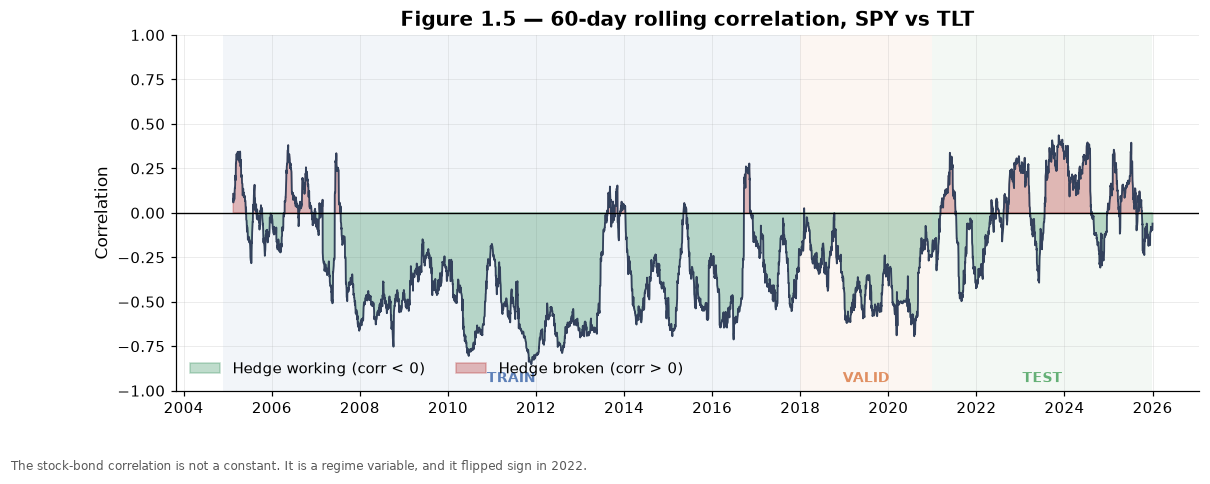

In [10]:
# Figure 1.5 — the single most important chart for motivating this project.
corr = returns["SPY"].rolling(CFG.vol_window_long).corr(returns["TLT"]).dropna()

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(corr.index, corr, color="#33415c", lw=1.2)

# Green where the hedge is working (negative correlation), red where it has failed.
ax.fill_between(corr.index, corr, 0, where=corr < 0, color="seagreen", alpha=0.30,
                interpolate=True, label="Hedge working (corr < 0)")
ax.fill_between(corr.index, corr, 0, where=corr >= 0, color="firebrick", alpha=0.30,
                interpolate=True, label="Hedge broken (corr > 0)")
ax.axhline(0, color="k", lw=0.9)

plots.shade_splits(ax, CFG)
ax.set_title("Figure 1.5 — 60-day rolling correlation, SPY vs TLT")
ax.set_ylabel("Correlation")
ax.set_ylim(-1, 1)
ax.legend(loc="lower left", ncol=2)
plots.tidy_dates(ax, interval=2)
plots.caption(fig, "The stock-bond correlation is not a constant. It is a regime variable, and it flipped sign in 2022.")

plots.save_fig(fig, "01_05_stock_bond_correlation")
plt.show()

**What this shows.** The stock–bond correlation is not a parameter, it is a *state
variable*. It sits mostly negative from 2005 to 2020 — the period during which
60/40 earned its reputation — and turns firmly positive in 2022, when rising rates
hit stocks and bonds simultaneously and the diversification benefit vanished at
exactly the moment it was needed.

This is the concrete opportunity the agent is being asked to exploit, and it is
why `spy_tlt_corr60` is included in the observation vector: **an agent cannot
rotate away from a broken hedge unless it can see the hedge breaking.**

It is also a warning. The regime change lands squarely in the *test* window, so
the agent must handle a correlation structure that was rare in training. That is a
hard generalisation test, and it is the honest one.

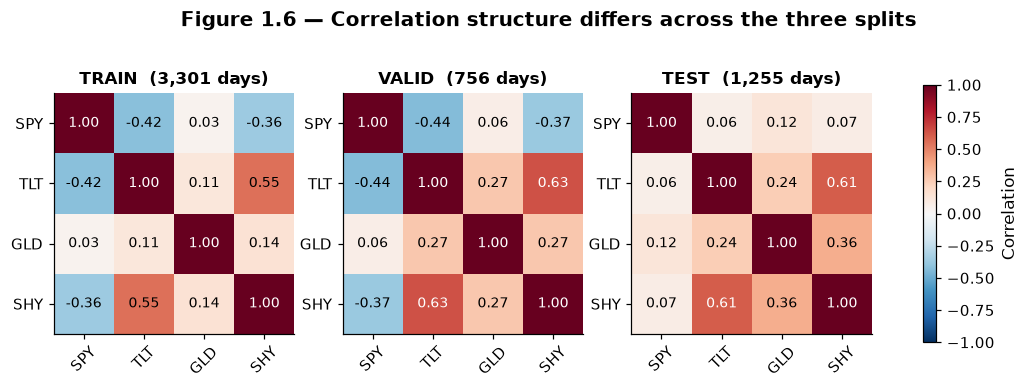

In [11]:
# Figure 1.6 — correlation structure computed separately within each split.
# If these three matrices were identical, the test set would be telling us
# nothing that the training set had not already said.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

for ax, split in zip(axes, ["train", "valid", "test"]):
    block = data.slice_split(returns, split, CFG)
    matrix = block.corr()

    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(matrix)), matrix.columns, rotation=45)
    ax.set_yticks(range(len(matrix)), matrix.index)
    ax.set_title(f"{split.upper()}  ({len(block):,} days)", fontsize=11)
    ax.grid(visible=False)

    # Annotate every cell: a heatmap without numbers invites over-reading.
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(value) > 0.55 else "black")

fig.colorbar(im, ax=axes, shrink=0.8, label="Correlation")
fig.suptitle("Figure 1.6 — Correlation structure differs across the three splits", fontweight="bold")

plots.save_fig(fig, "01_06_split_correlations")
plt.show()

**What this shows.** The SPY–TLT entry moves from clearly negative in training to
materially positive in the test window. The splits are therefore not exchangeable
draws from one distribution, and the out-of-sample evaluation is a genuine test of
**generalisation across regimes**, not merely across time.

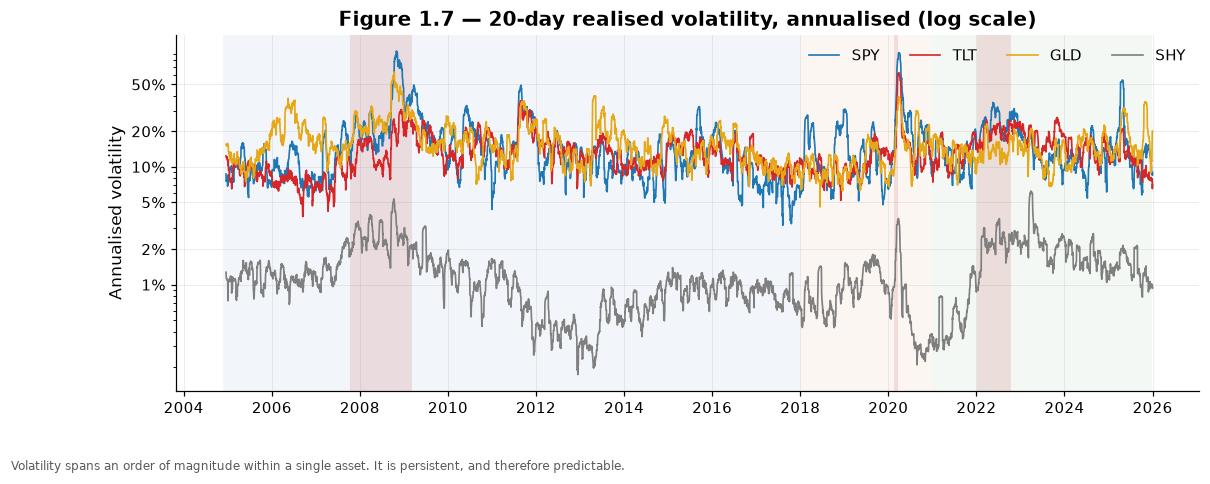

In [12]:
# Figure 1.7 — realised volatility, the feature the reward penalty acts on.
vol20 = returns.rolling(CFG.vol_window).std() * np.sqrt(config.TRADING_DAYS_PER_YEAR)

fig, ax = plt.subplots(figsize=(12, 4.2))
for ticker in vol20.columns:
    ax.plot(vol20.index, vol20[ticker], color=plots.ASSET_COLORS[ticker], label=ticker, lw=1.1)

ax.set_yscale("log")  # SHY sits ~20x below SPY; a linear axis would flatten it to zero
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0.01, 0.02, 0.05, 0.10, 0.20, 0.50])
plots.format_pct_axis(ax, decimals=0)

plots.annotate_crises(ax, label=False)
plots.shade_splits(ax, CFG, label=False)
ax.set_title("Figure 1.7 — 20-day realised volatility, annualised (log scale)")
ax.set_ylabel("Annualised volatility")
ax.legend(ncol=4, loc="upper right")
plots.tidy_dates(ax, interval=2)
plots.caption(fig, "Volatility spans an order of magnitude within a single asset. It is persistent, and therefore predictable.")

plots.save_fig(fig, "01_07_rolling_volatility")
plt.show()

**What this shows.** SPY's annualised volatility ranges from roughly 6% in calm
stretches to over 80% in March 2020 — more than an order of magnitude *within one
asset*. Two design consequences:

- Because volatility is persistent, `vol20` and `vol60` are genuinely informative
  state features rather than noise.
- Because the range is so wide, the feature scaler clips at ±5 training standard
  deviations. March 2020 sits roughly eight sigmas out; left unclipped, that single
  row would dominate the first layer's activations and destabilise early training.

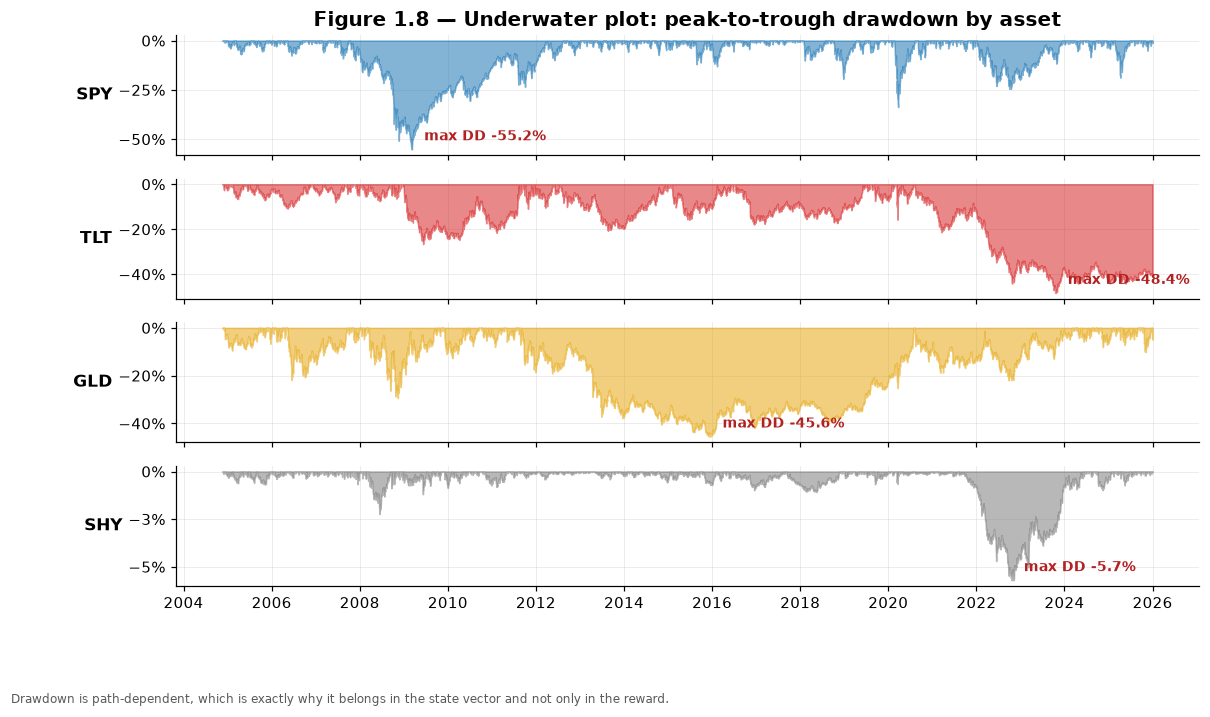

In [13]:
# Figure 1.8 — underwater plot. Drawdown is the risk measure the reward function
# actually penalises, so it gets its own figure rather than a summary statistic.
cumulative = (1 + returns).cumprod()
drawdown = cumulative / cumulative.cummax() - 1.0

fig, axes = plt.subplots(len(drawdown.columns), 1, figsize=(12, 6.5), sharex=True)

for ax, ticker in zip(axes, drawdown.columns):
    series = drawdown[ticker]
    ax.fill_between(series.index, series, 0, color=plots.ASSET_COLORS[ticker], alpha=0.55)
    ax.set_ylabel(ticker, rotation=0, ha="right", va="center", fontweight="bold")
    plots.format_pct_axis(ax, decimals=0)

    worst = series.min()
    ax.annotate(
        f"max DD {worst:.1%}",
        xy=(series.idxmin(), worst),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=9,
        color="firebrick",
        fontweight="bold",
    )

axes[0].set_title("Figure 1.8 — Underwater plot: peak-to-trough drawdown by asset")
plots.tidy_dates(axes[-1], interval=2)
plots.caption(fig, "Drawdown is path-dependent, which is exactly why it belongs in the state vector and not only in the reward.")

plots.save_fig(fig, "01_08_drawdowns")
plt.show()

**What this shows.** Every risk asset here has suffered a drawdown deep enough to
matter to a real investor, and — critically — **TLT's worst drawdown occurs in the
test window, not in training.** The "safe" leg of the classical 60/40 portfolio
produced a drawdown comparable in magnitude to the equity leg's during the GFC.

This also motivates a specific design choice in the reward function. Drawdown is
*path-dependent*: it depends on the running maximum, not on the current price
alone. Penalising the drawdown **level** at every step would charge the agent
repeatedly for one loss and teach it to sit in cash forever. The reward therefore
penalises the drawdown **increment** $\max(0, DD_t - DD_{t-1})$, and current
drawdown is included in the observation so the problem stays Markov.

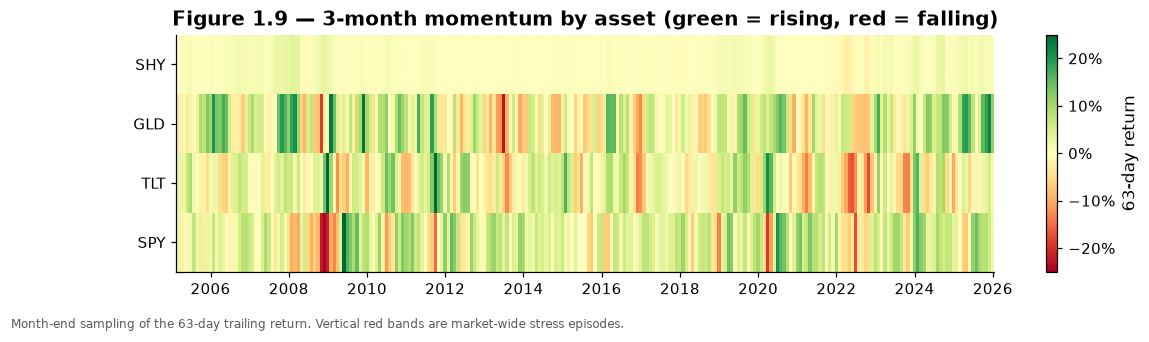

In [14]:
# Figure 1.9 — momentum regime map. Resampled to month-end so the image is a
# readable ~250 columns rather than 5,000 unresolvable pixel slivers.
momentum = prices.pct_change(CFG.momentum_window).resample("ME").last().dropna()

fig, ax = plt.subplots(figsize=(12, 2.8))
mesh = ax.pcolormesh(
    momentum.index,
    np.arange(len(momentum.columns)),
    momentum.T.to_numpy(),
    cmap="RdYlGn",
    vmin=-0.25,
    vmax=0.25,
    shading="nearest",
)
ax.set_yticks(np.arange(len(momentum.columns)), momentum.columns)
ax.grid(visible=False)
ax.set_title("Figure 1.9 — 3-month momentum by asset (green = rising, red = falling)")
fig.colorbar(mesh, ax=ax, label="63-day return", format=PercentFormatter(xmax=1.0, decimals=0))
plots.caption(fig, "Month-end sampling of the 63-day trailing return. Vertical red bands are market-wide stress episodes.")

plots.save_fig(fig, "01_09_momentum_regimes")
plt.show()

**What this shows.** Momentum is *rarely uniform across assets*. Most of the map
is mixed — some assets rising while others fall — which is precisely the condition
under which reallocation can add value. The fully-red vertical bands (2008, 2020,
2022) are the episodes where correlations converge to one and there is nowhere to
hide except the cash-like SHY leg. Those bands are the reason a 100% SHY action
exists in the action menu at all.

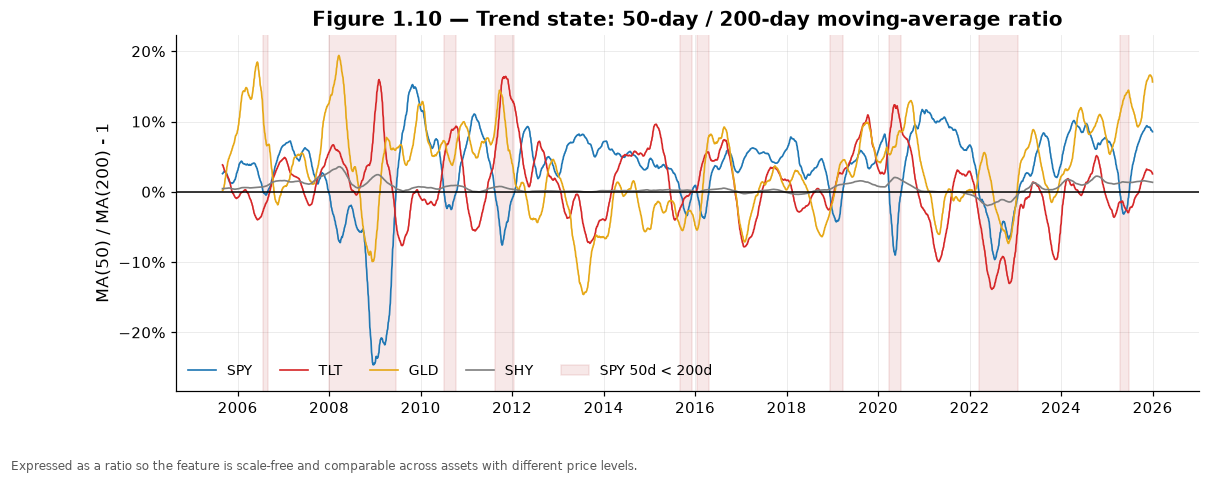

In [15]:
# Figure 1.10 — trend state: 50-day vs 200-day moving average.
ma_ratio = (
    prices.rolling(CFG.ma_fast).mean() / prices.rolling(CFG.ma_slow).mean() - 1.0
).dropna()

fig, ax = plt.subplots(figsize=(12, 4.2))
for ticker in ma_ratio.columns:
    ax.plot(ma_ratio.index, ma_ratio[ticker], color=plots.ASSET_COLORS[ticker], label=ticker, lw=1.1)

ax.axhline(0, color="k", lw=1.0)
# Shade the periods when SPY is in a "death cross" (fast MA below slow MA).
ax.fill_between(
    ma_ratio.index, -1, 1,
    where=ma_ratio["SPY"] < 0,
    color="firebrick", alpha=0.10, label="SPY 50d < 200d",
)
ax.set_ylim(ma_ratio.min().min() * 1.15, ma_ratio.max().max() * 1.15)
plots.format_pct_axis(ax, decimals=0)

ax.set_title("Figure 1.10 — Trend state: 50-day / 200-day moving-average ratio")
ax.set_ylabel("MA(50) / MA(200) - 1")
ax.legend(ncol=5, loc="lower left", fontsize=9)
plots.tidy_dates(ax, interval=2)
plots.caption(fig, "Expressed as a ratio so the feature is scale-free and comparable across assets with different price levels.")

plots.save_fig(fig, "01_10_trend_state")
plt.show()

**What this shows.** The trend feature is slow-moving and mean-reverting around
zero, and the shaded "death cross" periods line up with the drawdowns in Figure
1.8. It contributes information that momentum alone does not: momentum measures
*how far* price has moved, while the MA ratio measures *whether the move has
changed the longer-term trend* — a slower, less noisy signal.

## 6. Feature engineering — and a demonstration of look-ahead bias

The observation vector has **31 dimensions**:

| Block | Dim | Built by |
|---|---|---|
| Per-asset features (4 assets × `ret5`, `mom63`, `vol20`, `vol60`, `ma_ratio`) | 20 | this notebook |
| SPY/TLT 60-day correlation | 1 | this notebook |
| Risk-free level and 20-day change | 2 | this notebook |
| Current portfolio weights | 4 | environment (notebook 02) |
| Portfolio rolling volatility | 1 | environment |
| Current drawdown | 1 | environment |
| Drawdown duration | 1 | environment |
| Fraction of episode elapsed | 1 | environment |

The last eight are appended by the environment because they depend on the agent's
own trajectory. Including them is not cosmetic: **the reward penalises portfolio
volatility and drawdown, so without them the problem is not Markov** and the value
function is unlearnable in principle.

In [16]:
market_features = features.build_market_features(prices, rf, CFG)
display(features.describe_features(market_features.columns).head(12))
print(f"... {market_features.shape[1]} market features in total")

,asset,description
feature,,
SPY_ret5,SPY,Trailing 1-week total return
SPY_mom63,SPY,Trailing 3-month total return (momentum)
SPY_vol20,SPY,"Annualised realised volatility, 20-day window"
SPY_vol60,SPY,"Annualised realised volatility, 60-day window"
SPY_ma_ratio,SPY,"50-day / 200-day moving-average ratio, minus 1..."
TLT_ret5,TLT,Trailing 1-week total return
TLT_mom63,TLT,Trailing 3-month total return (momentum)
TLT_vol20,TLT,"Annualised realised volatility, 20-day window"
TLT_vol60,TLT,"Annualised realised volatility, 60-day window"


... 23 market features in total


### 6.1 The look-ahead trap, made visible

A rolling 20-day volatility computed *through* day $t$ contains day $t$'s return.
An agent observing it would see today's realised move and then be paid for a
position it is pretending to have taken *before* seeing it.

The fix is one character of code — `.shift(1)` — and it is easy to omit. The
figure below is a deliberate side-by-side of the correct and incorrect versions
during the COVID crash, so the reader can see the size of the distortion rather
than take the claim on trust.

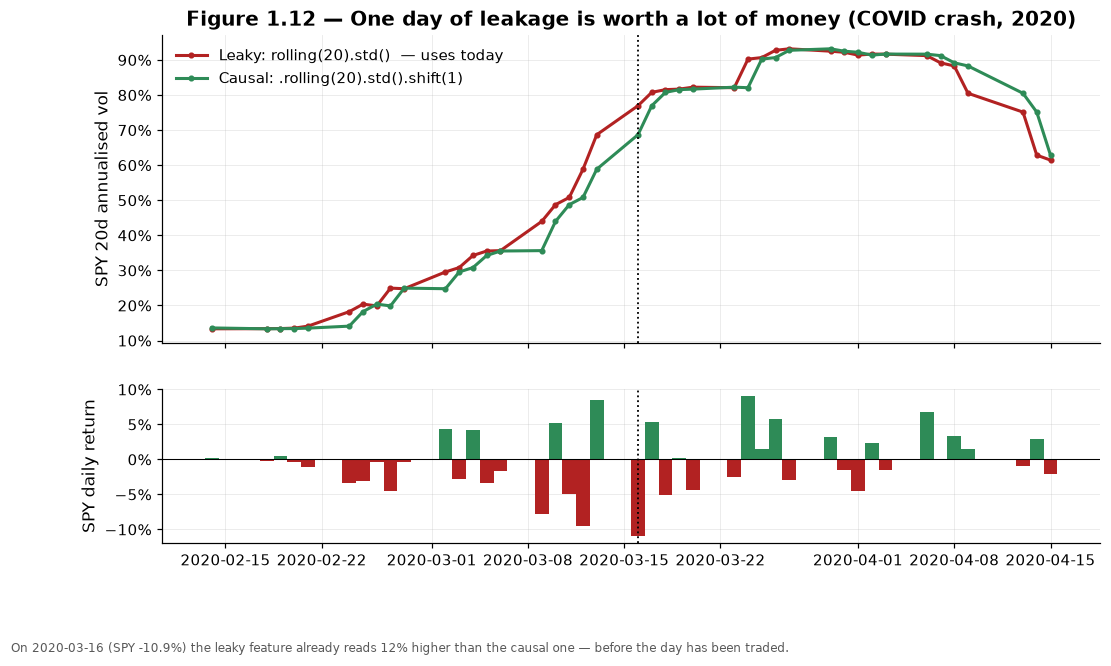

Leaky vol on 2020-03-16  : 77.0%
Causal vol on 2020-03-16 : 68.7%
Overstatement                    : 12.0%


In [17]:
# Figure 1.12 — leakage demonstration.
raw_vol = returns["SPY"].rolling(CFG.vol_window).std() * np.sqrt(config.TRADING_DAYS_PER_YEAR)
leaky = raw_vol                    # WRONG: row t already contains day t's return
causal = raw_vol.shift(1)          # CORRECT: row t knows only up to t-1

window = slice("2020-02-14", "2020-04-15")
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax_top.plot(leaky[window].index, leaky[window], color="firebrick", lw=2.0,
            marker="o", ms=3, label="Leaky: rolling(20).std()  — uses today")
ax_top.plot(causal[window].index, causal[window], color="seagreen", lw=2.0,
            marker="o", ms=3, label="Causal: .rolling(20).std().shift(1)")
ax_top.set_ylabel("SPY 20d annualised vol")
plots.format_pct_axis(ax_top, decimals=0)
ax_top.legend(loc="upper left")
ax_top.set_title("Figure 1.12 — One day of leakage is worth a lot of money (COVID crash, 2020)")

ax_bot.bar(returns[window].index, returns.loc[window, "SPY"],
           color=np.where(returns.loc[window, "SPY"] < 0, "firebrick", "seagreen"), width=1.0)
ax_bot.set_ylabel("SPY daily return")
plots.format_pct_axis(ax_bot, decimals=0)
ax_bot.axhline(0, color="k", lw=0.7)

worst_day = returns.loc[window, "SPY"].idxmin()
for ax in (ax_top, ax_bot):
    ax.axvline(worst_day, color="k", ls=":", lw=1.2)

gap = (leaky[worst_day] - causal[worst_day]) / causal[worst_day]
plots.caption(
    fig,
    f"On {worst_day.date()} (SPY {returns.loc[worst_day, 'SPY']:.1%}) the leaky feature already "
    f"reads {gap:.0%} higher than the causal one — before the day has been traded.",
)

plots.save_fig(fig, "01_12_lookahead_demo")
plt.show()

print(f"Leaky vol on {worst_day.date()}  : {leaky[worst_day]:.1%}")
print(f"Causal vol on {worst_day.date()} : {causal[worst_day]:.1%}")
print(f"Overstatement                    : {gap:.1%}")

**What this shows.** On the worst day of the COVID crash the leaky feature has
*already jumped* — it encodes the crash on the very day the crash happens. An
agent trained on it would appear to have learned to de-risk with uncanny timing,
when in fact it was simply reading the answer.

`portfoliorl.features.build_market_features` applies `.shift(1)` to the entire
feature matrix as the final operation, and `tests/test_features.py` enforces it
with a perturbation test: shocking the price on day $k$ must leave every feature
row up to and including $k$ bit-for-bit unchanged. Removing the shift fails that
test immediately.

## 7. Assemble and standardise the dataset

Order of operations matters, and this is the part most often got wrong:

1. build causal features (shift by one day);
2. trim the look-back warm-up **before** the training window opens — so the
   training period is never silently shortened by dropping NaNs inside it;
3. fit the scaler on the **training rows only**;
4. apply that same fitted scaler to validation and test.

Fitting the scaler on the full sample would leak the mean and variance of the test
period into training. It is a subtle form of look-ahead and a well-documented
source of irreproducible results in quantitative finance.

In [18]:
dataset = features.build_dataset(prices, rf, CFG)

summary = pd.DataFrame(
    [
        {
            "split": name,
            "days": len(part.prices),
            "start": part.dates.min().date(),
            "end": part.dates.max().date(),
            "years": round(len(part.prices) / config.TRADING_DAYS_PER_YEAR, 1),
            "weekly decisions": len(part.prices) // config.DEFAULT.env.steps_per_decision,
        }
        for name in ("train", "valid", "test")
        for part in [dataset.split(name, CFG)]
    ]
).set_index("split")

display(summary.style.set_caption("Table 2 — Chronological split sizes"))
print(f"Market features : {dataset.n_market_features}")
print(f"Observation dim : {dataset.obs_dim}  (= {dataset.n_market_features} market + "
      f"{features.N_PORTFOLIO_FEATURES} portfolio state)")

,days,start,end,years,weekly decisions
split,,,,,
train,3102,2005-09-06,2017-12-29,12.300000,620
valid,756,2018-01-02,2020-12-31,3.000000,151
test,1255,2021-01-04,2025-12-31,5.000000,251


Market features : 23
Observation dim : 31  (= 23 market + 8 portfolio state)


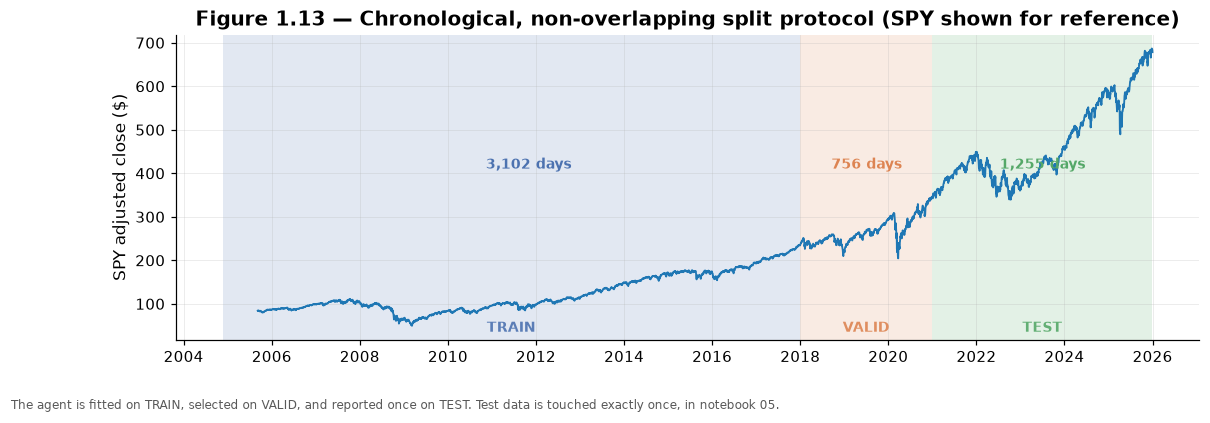

In [19]:
# Figure 1.13 — the split protocol, drawn.
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(dataset.prices.index, dataset.prices["SPY"], color=plots.ASSET_COLORS["SPY"], lw=1.2)
plots.shade_splits(ax, CFG, alpha=0.16)

for name in ("train", "valid", "test"):
    part = dataset.split(name, CFG)
    ax.annotate(
        f"{len(part.prices):,} days",
        xy=(part.dates[len(part.dates) // 2], 0.55),
        xycoords=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=9, color=plots.SPLIT_COLORS[name], fontweight="bold",
    )

ax.set_title("Figure 1.13 — Chronological, non-overlapping split protocol (SPY shown for reference)")
ax.set_ylabel("SPY adjusted close ($)")
plots.tidy_dates(ax, interval=2)
plots.caption(fig, "The agent is fitted on TRAIN, selected on VALID, and reported once on TEST. Test data is touched exactly once, in notebook 05.")

plots.save_fig(fig, "01_13_split_protocol")
plt.show()

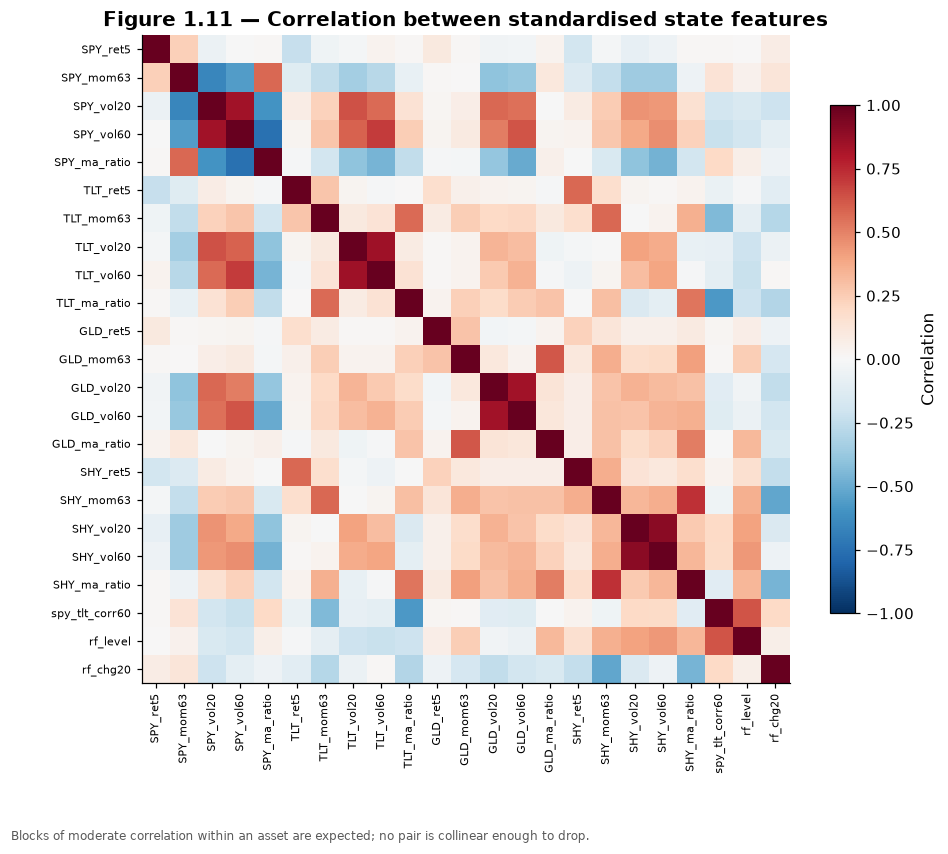

Most correlated feature pairs:


,,|corr|
SHY_vol20,SHY_vol60,0.902350
TLT_vol20,TLT_vol60,0.844272
SPY_vol20,SPY_vol60,0.842817
GLD_vol20,GLD_vol60,0.839707
SPY_vol60,SPY_ma_ratio,0.749942
SHY_mom63,SHY_ma_ratio,0.732572


In [20]:
# Figure 1.11 — feature correlation structure.
# Purpose: detect redundancy. Perfectly collinear inputs waste network capacity
# and make the learned weights unidentifiable.
feature_corr = dataset.features.corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(feature_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_corr)), feature_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_corr)), feature_corr.index, fontsize=7)
ax.grid(visible=False)
ax.set_title("Figure 1.11 — Correlation between standardised state features")
fig.colorbar(im, ax=ax, shrink=0.75, label="Correlation")

# Report the strongest off-diagonal pairs numerically rather than asking the
# reader to eyeball a 23x23 grid.
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool)).stack()
plots.caption(fig, "Blocks of moderate correlation within an asset are expected; no pair is collinear enough to drop.")

plots.save_fig(fig, "01_11_feature_correlations")
plt.show()

print("Most correlated feature pairs:")
display(upper.abs().sort_values(ascending=False).head(6).rename("|corr|").to_frame())

**What this shows.** The two volatility horizons within an asset are strongly
correlated, as expected — but not identically, and their *difference* is the
regime-change signal, so both are retained. No pair is collinear to the point of
being redundant, so all 23 market features go into the observation. With only
~12,500 network parameters there is no pressing capacity argument for pruning.

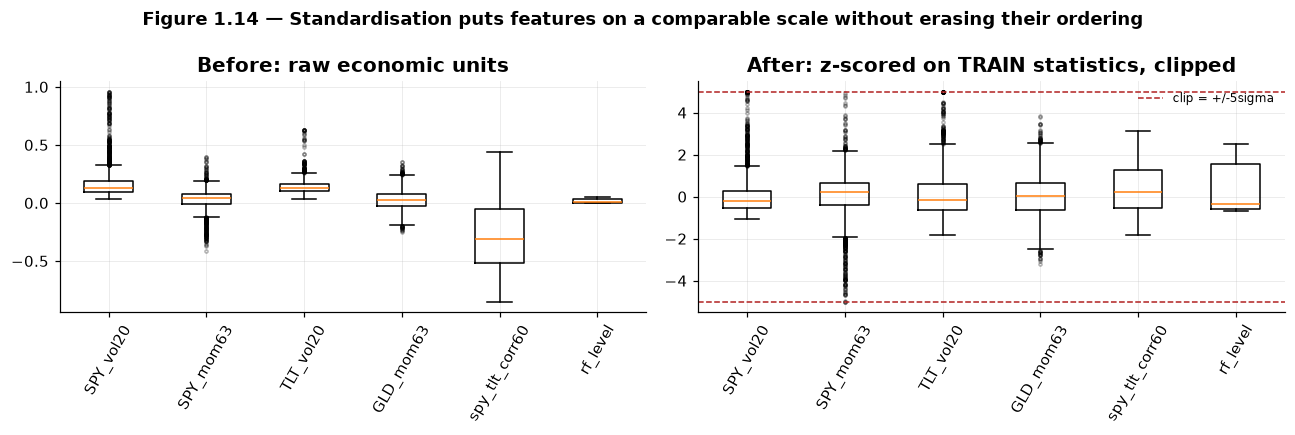

In [21]:
# Figure 1.14 — the effect of train-fit standardisation.
sample_cols = ["SPY_vol20", "SPY_mom63", "TLT_vol20", "GLD_mom63", "spy_tlt_corr60", "rf_level"]

fig, (ax_raw, ax_scaled) = plt.subplots(1, 2, figsize=(12, 4))

ax_raw.boxplot([dataset.features_raw[c] for c in sample_cols], tick_labels=sample_cols,
               showfliers=True, flierprops={"markersize": 2, "alpha": 0.3})
ax_raw.set_title("Before: raw economic units")
ax_raw.tick_params(axis="x", rotation=60)

ax_scaled.boxplot([dataset.features[c] for c in sample_cols], tick_labels=sample_cols,
                  showfliers=True, flierprops={"markersize": 2, "alpha": 0.3})
ax_scaled.axhline(dataset.scaler.clip, color="firebrick", ls="--", lw=1,
                  label=f"clip = +/-{dataset.scaler.clip:g}sigma")
ax_scaled.axhline(-dataset.scaler.clip, color="firebrick", ls="--", lw=1)
ax_scaled.set_title("After: z-scored on TRAIN statistics, clipped")
ax_scaled.tick_params(axis="x", rotation=60)
ax_scaled.legend(fontsize=8)

fig.suptitle("Figure 1.14 — Standardisation puts features on a comparable scale without erasing their ordering",
             fontweight="bold", fontsize=12)
fig.tight_layout()

plots.save_fig(fig, "01_14_scaling_effect")
plt.show()

**What this shows.** Before scaling, `rf_level` (0–0.05) and `SPY_mom63`
(−0.4 to +0.4) differ by an order of magnitude, so a randomly-initialised network
would effectively ignore the smaller one for many thousands of gradient steps.
After scaling they are comparable, and the ±5σ clip bounds the extreme rows
while preserving their rank — the agent still knows March 2020 was exceptional,
it just is not allowed to saturate the first layer.

## 8. Persist the processed dataset

Notebooks 02–05 load these files rather than rebuilding the dataset. That makes
the pipeline a genuine DAG — this notebook produces, the others consume — and
removes any possibility of a later notebook silently using a different
configuration or a different data snapshot.

In [22]:
out_dir = features.save_dataset(dataset)

print(f"Processed dataset written to {out_dir}")
for path in sorted(out_dir.iterdir()):
    print(f"  {path.name:<22} {path.stat().st_size / 1024:8.1f} KB")

figures = sorted(config.ARTIFACTS_FIGURES.glob("01_*.png"))
print(f"\n{len(figures)} figures written to {config.ARTIFACTS_FIGURES}")
for path in figures:
    print(f"  {path.name}")

# Round-trip check: what the next notebook loads must equal what this one built.
reloaded = features.load_dataset()
pd.testing.assert_frame_equal(reloaded.features, dataset.features)
print("\nRound-trip check passed: reloaded dataset is identical to the one built here.")

Processed dataset written to C:\Github\PortfolioRL\data\processed
  features_raw.csv         2432.9 KB
  features_scaled.csv      2318.2 KB
  prices.csv                418.5 KB
  returns.csv               488.6 KB
  risk_free.csv             165.9 KB
  scaler.json                 2.3 KB

14 figures written to C:\Github\PortfolioRL\artifacts\figures
  01_01_asset_growth.png
  01_02_data_coverage.png
  01_03_daily_returns.png
  01_04_return_distributions.png
  01_05_stock_bond_correlation.png
  01_06_split_correlations.png
  01_07_rolling_volatility.png
  01_08_drawdowns.png
  01_09_momentum_regimes.png
  01_10_trend_state.png
  01_11_feature_correlations.png
  01_12_lookahead_demo.png
  01_13_split_protocol.png
  01_14_scaling_effect.png



Round-trip check passed: reloaded dataset is identical to the one built here.


---

## Key takeaways

1. **The dataset is clean and frozen.** 5,313 trading days across four ETFs,
   zero missing observations, zero suspect ticks, realised volatilities matching
   published fund characteristics. All results are reproducible from `data/raw/`.
2. **The features are provably causal.** `.shift(1)` is applied to the whole
   feature matrix and enforced by a perturbation test. Figure 1.12 quantifies what
   omitting it would buy — and it is a lot.
3. **A dynamic policy has something real to exploit.** Volatility clusters
   (Fig. 1.3, 1.7), momentum is rarely uniform across assets (Fig. 1.9), and the
   stock–bond correlation flips sign (Fig. 1.5). None of these are exploitable by
   a static allocation.
4. **The test window is genuinely out-of-regime.** The SPY–TLT correlation, and
   TLT's worst drawdown in the sample, both sit in the test period. The
   out-of-sample result will be an honest test of generalisation.
5. **Returns are fat-tailed and skewed**, which is why the results section reports
   Sortino and maximum drawdown alongside Sharpe, and uses a block bootstrap
   rather than an i.i.d. normal confidence interval.

**Next:** `02_env_benchmarks.ipynb` — build the Gymnasium environment around this
dataset, verify it against an independently-computed portfolio, and establish the
benchmark scorecard the agent must beat.